# Project 1 - NASA Battery EDA
- dataset: https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip

In [30]:
# library import
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# extract data from .mat file
mat = scipy.io.loadmat('data/B0005.mat')
b = mat['B0005']
print(type(b))
print(b.dtype)
print(b.shape)

<class 'numpy.ndarray'>
[('cycle', 'O')]
(1, 1)


In [8]:
cycles = b[0, 0]['cycle']
print(type(cycles))
print(cycles.shape)
print(cycles.dtype)

<class 'numpy.ndarray'>
(1, 616)
[('type', 'O'), ('ambient_temperature', 'O'), ('time', 'O'), ('data', 'O')]


In [10]:
c0 = cycles[0, 0]
print('type:', c0['type'])
print('ambient_temperature:', c0['ambient_temperature'])

data = c0['data']
print('data dtype:', data.dtype)

type: ['charge']
ambient_temperature: [[24]]
data dtype: [('Voltage_measured', 'O'), ('Current_measured', 'O'), ('Temperature_measured', 'O'), ('Current_charge', 'O'), ('Voltage_charge', 'O'), ('Time', 'O')]


In [33]:
record = []

for i in range(cycles.shape[1]):
    c = cycles[0, i]
    cyc_type = str(c['type'][0])
    cyc_temp = c['ambient_temperature'][0, 0]
    cyc_data = c['data'][0,0]

    if cyc_type == 'discharge':
        cyc_vol = cyc_data['Voltage_measured'][0].flatten()
        cyc_cur = cyc_data['Current_measured'][0].flatten()
        cyc_time = cyc_data['Time'][0].flatten()

        cyc_capa = np.trapz(abs(cyc_cur), cyc_time) / 3600
        record.append({'index': i, 'temp': cyc_temp, 'capa(Ah)': round(cyc_capa, 4)})

df = pd.DataFrame(record)
# calculate state of health (SOH): SOH = capa(Ah) / capa(Ah) at 1st cycle
# capa(Ah) at 1st cycle is the initial capacity of the battery, which is used as a reference to evaluate the health of the battery over time.
# Don't know the type of battery or cathode material, unable to compare absolute values
df['SOH'] = df['capa(Ah)'] / df['capa(Ah)'].iloc[0]
df = df.reset_index(drop=True)
print(df.head())
print(df.shape)

   index  temp  capa(Ah)       SOH
0      1    24    1.8622  1.000000
1      3    24    1.8521  0.994576
2      5    24    1.8410  0.988616
3      7    24    1.8409  0.988562
4      9    24    1.8404  0.988293
(168, 4)


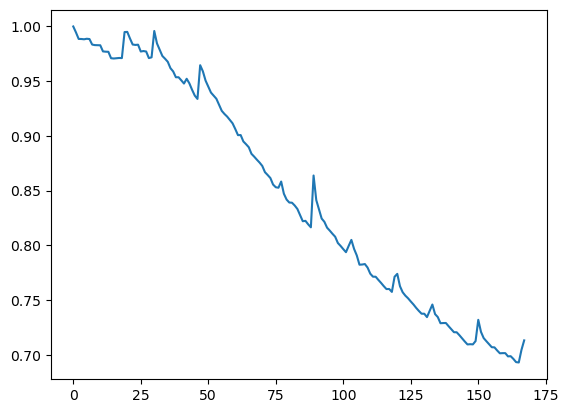

In [35]:
plt.plot(df.index, df['SOH']);

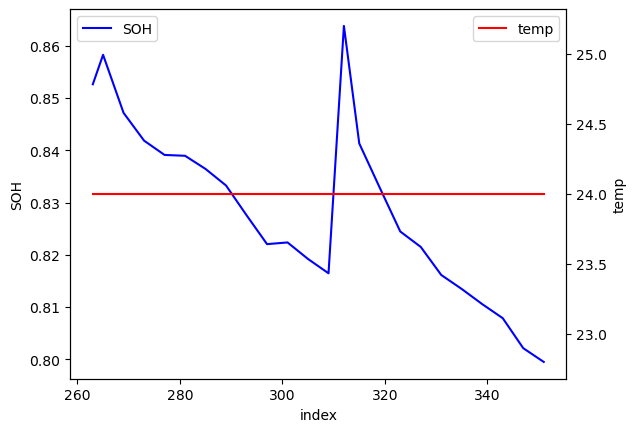

In [45]:
temp_df = df.loc[(df.index > 75) & (df.index < 100)]

ax = temp_df.plot(x='index', y='SOH', color='blue', label='SOH')
ax2 = ax.twinx()
temp_df.plot(x='index', y='temp', color='red', label='temp', ax=ax2)
ax.set_xlabel('index')
ax.set_ylabel('SOH')
ax2.set_ylabel('temp')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

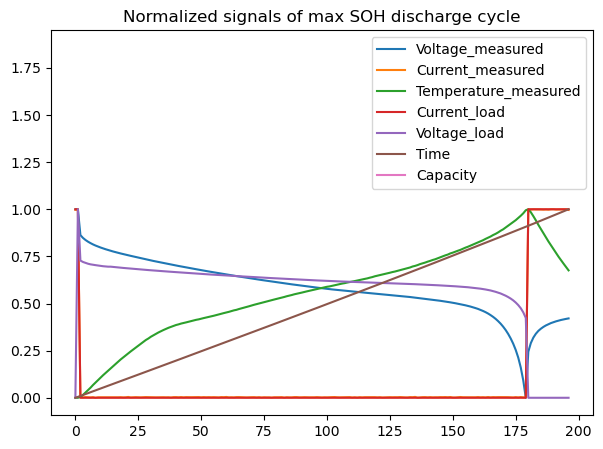

In [68]:
# dive into normal random SOH discharge cycle's data 
# No special pattern observed
specific_soh_index = df.loc[df['SOH'].idxmax(), 'index']
specific_soh_cyc = cycles[0, specific_soh_index]

plt.figure(figsize=(7,5))
for key in specific_soh_cyc['data'].dtype.names:
    arr = specific_soh_cyc['data'][key][0,0].flatten()
    # 정규화
    arr_norm = (arr - arr.min()) / (arr.max() - arr.min()) if arr.max() != arr.min() else arr
    plt.plot(arr_norm, label=key)
plt.legend()
plt.title("Normalized signals of max SOH discharge cycle")
plt.show()

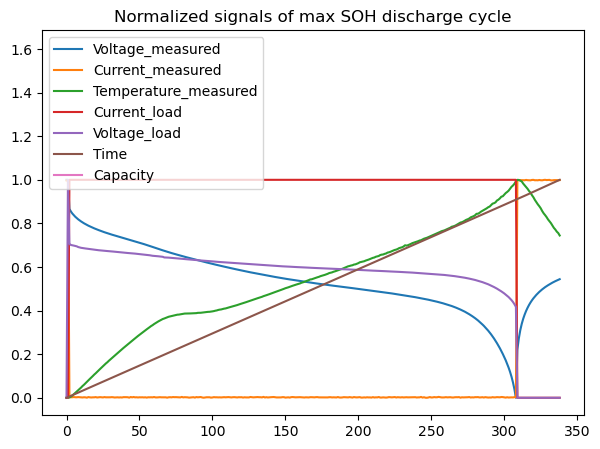

In [69]:
# dive into max SOH discharge cycle's data 
# outlier CC-CV pattern observed. cycle length is much longer than normal one
specific_soh_index = temp_df.loc[temp_df['SOH'].idxmax(), 'index']
specific_soh_cyc = cycles[0, specific_soh_index]

plt.figure(figsize=(7,5))
for key in specific_soh_cyc['data'].dtype.names:
    arr = specific_soh_cyc['data'][key][0,0].flatten()
    # 정규화
    arr_norm = (arr - arr.min()) / (arr.max() - arr.min()) if arr.max() != arr.min() else arr
    plt.plot(arr_norm, label=key)
plt.legend()
plt.title("Normalized signals of max SOH discharge cycle")
plt.show()

In [96]:
# longer discharge cycle length is observed in max SOH discharge cycle compared to normal random SOH discharge cycle
# resulting larger SOH 
print(len(cycles[0, 305]['data']['Time'][0,0].flatten()))
print(len(cycles[0, 312]['data']['Time'][0,0].flatten()))
print(len(cycles[0, 319]['data']['Time'][0,0].flatten()))

326
339
328


# ANOVA
- 3가지 온도 조건 배터리 ANOVA — B0005/B0006/B0007이 각각 다른 온도에서 테스트됐는지 확인하고, 온도별로 수명(capacity)에 유의미한 차이가 있는지 통계 검정

In [113]:
# import B0005,B0006,B0007
# Same ambient temperature is observed in all three batteries, which is 24 degree Celsius
mat5 = scipy.io.loadmat('data/B0005.mat')['B0005']
mat6 = scipy.io.loadmat('data/B0006.mat')['B0006']
mat7 = scipy.io.loadmat('data/B0007.mat')['B0007']

cycles_5 = mat5[0, 0]['cycle']
cycles_6 = mat6[0, 0]['cycle']
cycles_7 = mat7[0, 0]['cycle']

print(cycles_5[0,0]['ambient_temperature'], cycles_6[0,0]['ambient_temperature'], cycles_7[0,0]['ambient_temperature'])


[[24]] [[24]] [[24]]


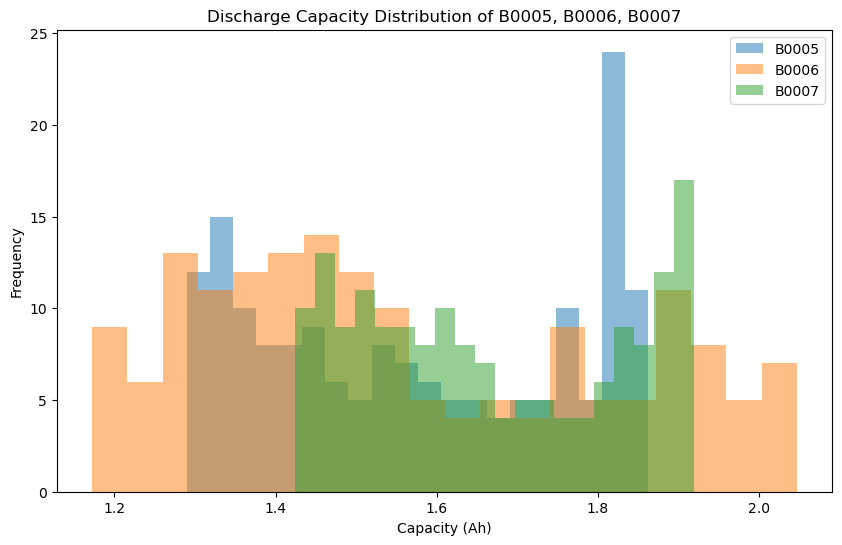

In [116]:
# capacity distribution analysis in 3 batteries
capa_5 = []
for i in range(cycles_5.shape[1]):
    c = cycles_5[0, i]
    cyc_type = str(c['type'][0])
    if cyc_type == 'discharge':
        cyc_cur = c['data'][0,0]['Current_measured'][0].flatten()
        cyc_time = c['data'][0,0]['Time'][0].flatten()
        cyc_capa = np.trapz(abs(cyc_cur), cyc_time) / 3600
        capa_5.append(cyc_capa)

capa_6 = []
for i in range(cycles_6.shape[1]):
    c = cycles_6[0, i]
    cyc_type = str(c['type'][0])
    if cyc_type == 'discharge':
        cyc_cur = c['data'][0,0]['Current_measured'][0].flatten()
        cyc_time = c['data'][0,0]['Time'][0].flatten()
        cyc_capa = np.trapz(abs(cyc_cur), cyc_time) / 3600
        capa_6.append(cyc_capa)

capa_7 = []
for i in range(cycles_7.shape[1]):
    c = cycles_7[0, i]
    cyc_type = str(c['type'][0])
    if cyc_type == 'discharge':
        cyc_cur = c['data'][0,0]['Current_measured'][0].flatten()
        cyc_time = c['data'][0,0]['Time'][0].flatten()
        cyc_capa = np.trapz(abs(cyc_cur), cyc_time) / 3600
        capa_7.append(cyc_capa)

plt.figure(figsize=(10,6))
plt.hist(capa_5, bins=20, alpha=0.5, label='B0005')
plt.hist(capa_6, bins=20, alpha=0.5, label='B0006')
plt.hist(capa_7, bins=20, alpha=0.5, label='B0007')
plt.xlabel('Capacity (Ah)')
plt.ylabel('Frequency')
plt.title('Discharge Capacity Distribution of B0005, B0006, B0007')
plt.legend()
plt.show()

In [ ]:
# ANOVA test for capacity distribution comparison
# result: at least 1 battery's capacity distribution is significantly different from the others
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(capa_5, capa_6, capa_7)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

ANOVA F-statistic: 13.1191, p-value: 0.0000


In [ ]:
# tukey HSD test for pairwise comparison
# result: B0005-B0006, B0005-B0007 are significantly different, while B0006-B0007 are not significantly different
from statsmodels.stats.multicomp import pairwise_tukeyhsd
data = capa_5 + capa_6 + capa_7
labels = ['B0005'] * len(capa_5) + ['B0006'] * len(capa_6) + ['B0007'] * len(capa_7)
tukey_result = pairwise_tukeyhsd(data, labels)
print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 B0005  B0006  -0.0152  0.773 -0.0674  0.037  False
 B0005  B0007     0.09 0.0002  0.0378 0.1422   True
 B0006  B0007   0.1052    0.0   0.053 0.1574   True
---------------------------------------------------
